# Tropical Cyclone Loss Model - Refactored Pipeline

Here we validate the new class type architecture in a clean way. We import the NatCat modules and then get the storm track via the setup preprocessing pipeline and then calculate the loss. 

In [1]:
# Autorelaode all modules when they change
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('../src')

from hazards.tropical_cyclone import TropicalCycloneHazard
from vulnerability import WindVulnerability
from loss_model import LossCalculator

from preprocessing.tropical_cyclone import preprocess_B_deck

from preprocessing.tropical_cyclone import get_country_exposure_via_api, convert_to_loss_model_format



## Test for B deck

In [65]:
# Test with Michael (2018) - Atlantic storm #14
year = 2018
basin = 'al'           # Atlantic
storm_number = '14'    # Storm number (2 digits)

# Preprocessing pipeline 
df_track = preprocess_B_deck(year, basin, storm_number, verbose=1)

# Initialize models
hazard = TropicalCycloneHazard(df_track)
vulnerability = WindVulnerability()
loss = LossCalculator(hazard, vulnerability)

# Load portfolio via API and convert to loss model format
portfolio = get_country_exposure_via_api("USA", [24.5, 32.0, -87.6, -80.0])
portfolio = convert_to_loss_model_format(portfolio)

# Calculate losses
results = loss.calculate_portfolio_loss(portfolio)
print(f"\nTotal loss: ${loss.total_loss:,.0f}")
results.describe()

Year is 2018. Checking ARCHIVE source...


1it [00:00, 6213.78it/s]


Downloaded to /Users/wirths/Documents/Private/NatCat/src/preprocessing/tropical_cyclone/../../../data/raw/bal142018.dat.gz
Extracted to /Users/wirths/Documents/Private/NatCat/src/preprocessing/tropical_cyclone/../../../data/raw/bal142018.dat
Extracted track file: /Users/wirths/Documents/Private/NatCat/src/preprocessing/tropical_cyclone/../../../data/raw/bal142018.dat
Initializing CLIMADA Data Client...
Downloading/Loading USA exposure data (this may take a moment)...
Filtering for subregion: [24.5, 32.0, -87.6, -80.0]...

Total loss: $16,162,950,242


,location_id,latitude,longitude,tiv,intensity,damage_ratio,loss
count,12201.000000,12201.000000,12201.000000,1.220100e+04,12201.000000,12201.000000,1.220100e+04
mean,6101.000000,29.632747,-83.112308,4.175408e+08,23.539590,0.028442,1.324723e+06
std,3522.269652,1.868173,1.979593,1.706952e+09,25.458563,0.139990,4.458057e+07
min,1.000000,24.604167,-87.562500,0.000000e+00,7.322856,0.000000,0.000000e+00
25%,3051.000000,28.104167,-84.645833,5.680825e+04,11.594512,0.000000,0.000000e+00
50%,6101.000000,30.270833,-82.520833,6.042423e+05,13.473317,0.000000,0.000000e+00
75%,9151.000000,31.187500,-81.562500,1.960020e+07,22.815472,0.000000,0.000000e+00
max,12201.000000,31.979167,-80.062500,3.383002e+10,145.762161,0.993811,2.684730e+09


## Test timestamp specific calculations 

In [66]:
start = pd.to_datetime("2018-10-06 00:00:00")
desired = pd.date_range(start=start, end=df_track.time.max(), freq='6H')
timestamps = df_track.time[df_track.time.isin(desired)]

In [67]:
results_timeevo = loss.calculate_portfolio_loss_over_time(portfolio, desired)
results_timeevo.head()

,location_id,latitude,longitude,tiv,construction,timestamp,intensity,damage_ratio,loss
0,1,31.979167,-87.562500,13409239.31,Masonry,2018-10-06,0.0,0.0,0.0
1,2,31.979167,-87.520833,995530.61,Frame,2018-10-06,0.0,0.0,0.0
2,3,31.979167,-87.479167,7928357.52,Frame,2018-10-06,0.0,0.0,0.0
3,4,31.979167,-87.437500,229593.69,Frame,2018-10-06,0.0,0.0,0.0
4,5,31.979167,-87.395833,142238.63,Masonry,2018-10-06,0.0,0.0,0.0


In [68]:
for timestamp in results_timeevo.timestamp.unique():
    results_timeevo_subset = results_timeevo[results_timeevo.timestamp == timestamp]
    #results_timeevo_subset.loss.sum()
    print(f"Total loss at {timestamp}: ${results_timeevo_subset.loss.sum():,.0f}")

Total loss at 2018-10-06 00:00:00: $0
Total loss at 2018-10-06 06:00:00: $0
Total loss at 2018-10-06 12:00:00: $0
Total loss at 2018-10-06 18:00:00: $0
Total loss at 2018-10-07 00:00:00: $0
Total loss at 2018-10-07 06:00:00: $0
Total loss at 2018-10-07 12:00:00: $0
Total loss at 2018-10-07 18:00:00: $0
Total loss at 2018-10-08 00:00:00: $0
Total loss at 2018-10-08 06:00:00: $0
Total loss at 2018-10-08 12:00:00: $0
Total loss at 2018-10-08 18:00:00: $0
Total loss at 2018-10-09 00:00:00: $0
Total loss at 2018-10-09 06:00:00: $0
Total loss at 2018-10-09 12:00:00: $0
Total loss at 2018-10-09 18:00:00: $0
Total loss at 2018-10-10 00:00:00: $0
Total loss at 2018-10-10 06:00:00: $0
Total loss at 2018-10-10 12:00:00: $0
Total loss at 2018-10-10 18:00:00: $14,226,901,384
Total loss at 2018-10-11 00:00:00: $15,939,133,517
Total loss at 2018-10-11 06:00:00: $16,159,261,369
Total loss at 2018-10-11 12:00:00: $16,162,950,242
Total loss at 2018-10-11 18:00:00: $16,162,950,242
Total loss at 2018-10-1

## Test visulaization 

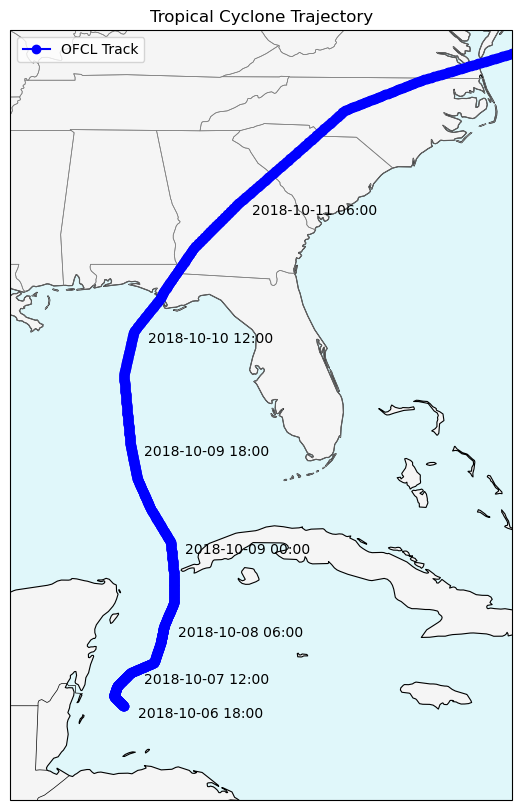

In [69]:
from visualization import plot_trajectory

fig = plot_trajectory(df_track,filestring='../plots/michael_trajectory.png')

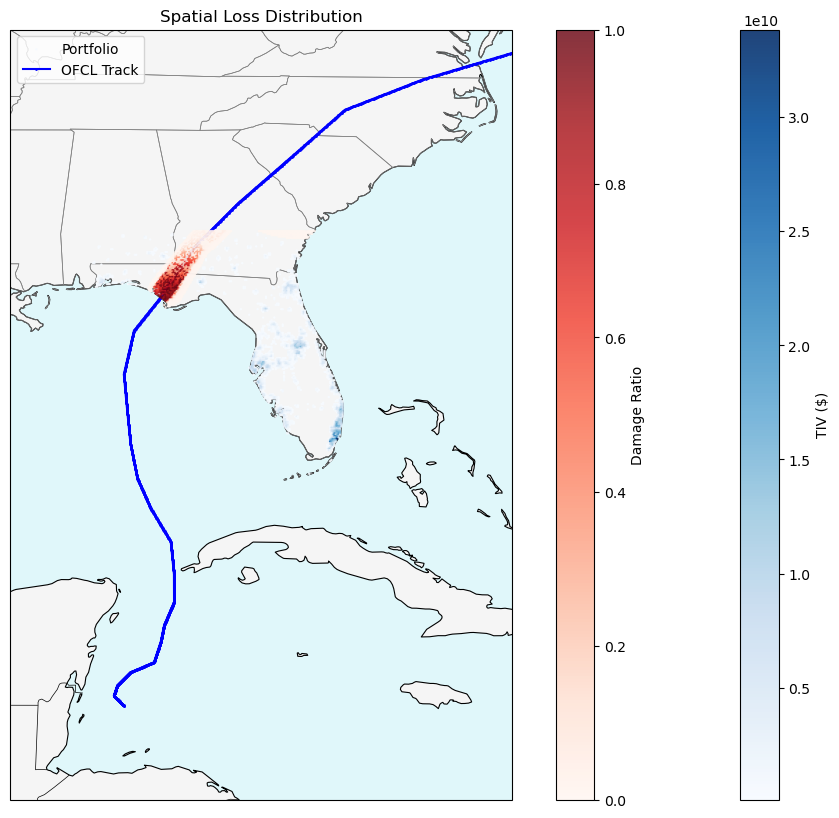

In [70]:
from visualization import spatial_loss
fig = spatial_loss(results_timeevo,portfolio=portfolio, damage_ratio=True, df_track=df_track, filestring='../plots/michael_damage_evolution.png')

## Temporal Animation of Loss Evolution

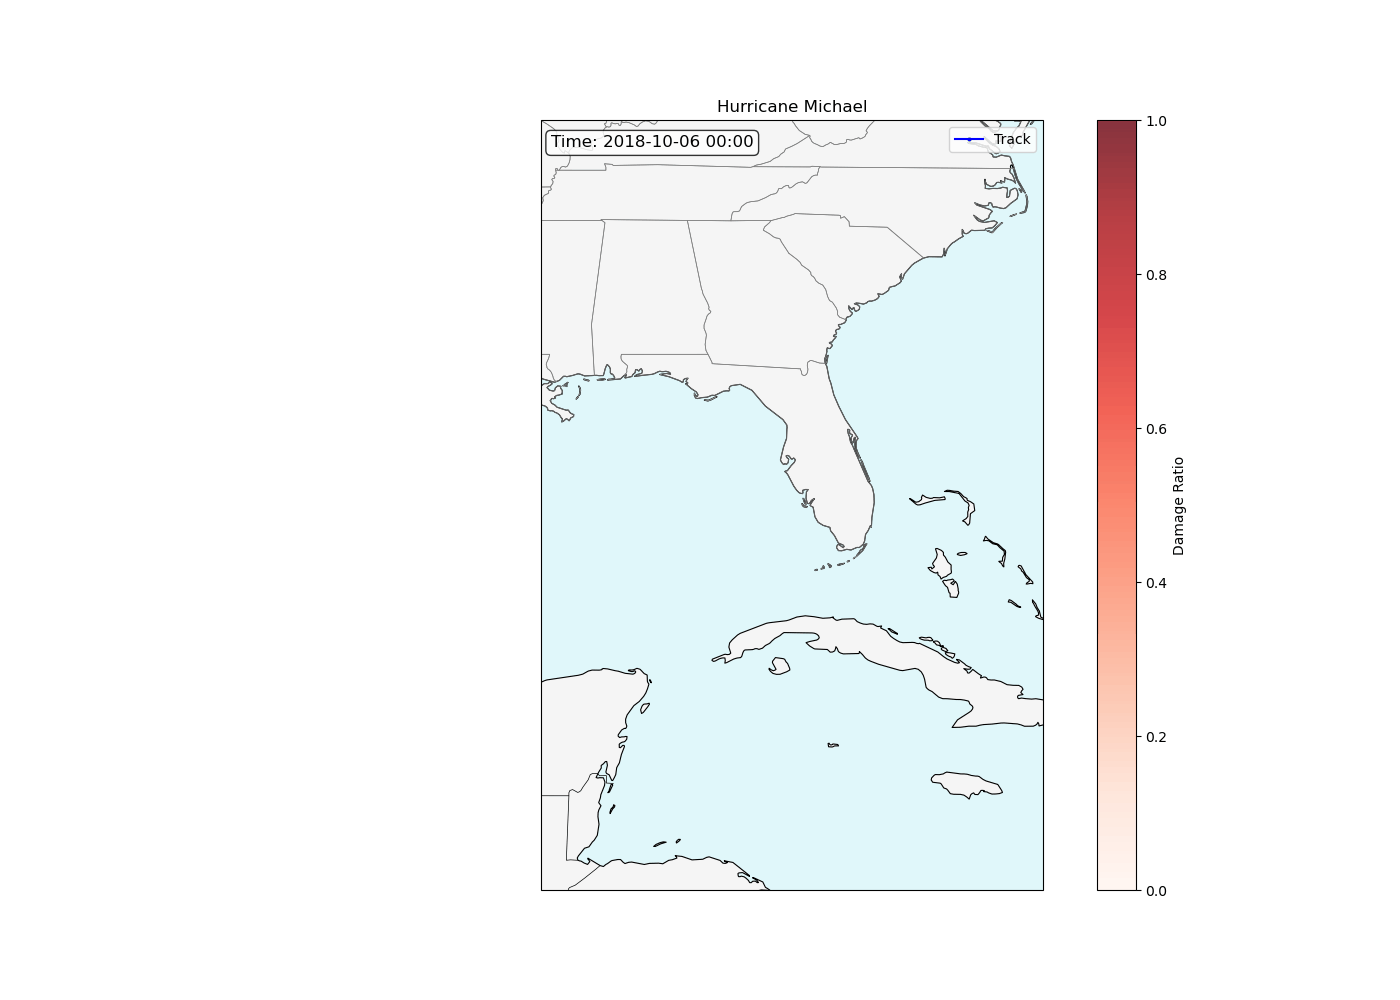

In [71]:
# Temporal animation of Hurricane Michael damage evolution
from visualization.tropical_cyclone import animate_spatial_loss
import os

#os.makedirs('../animations', exist_ok=True)

# Use the time-evolution results
anim = animate_spatial_loss(
    df_loss=results_timeevo,
    df_track=df_track,
    damage_ratio=True,
    timestep_hours=6,
    filestring='../animations/michael_damage_evolution.gif',
    title='Hurricane Michael',
    fps=2
)

from IPython.display import Image
Image(filename='../animations/michael_damage_evolution.gif')
